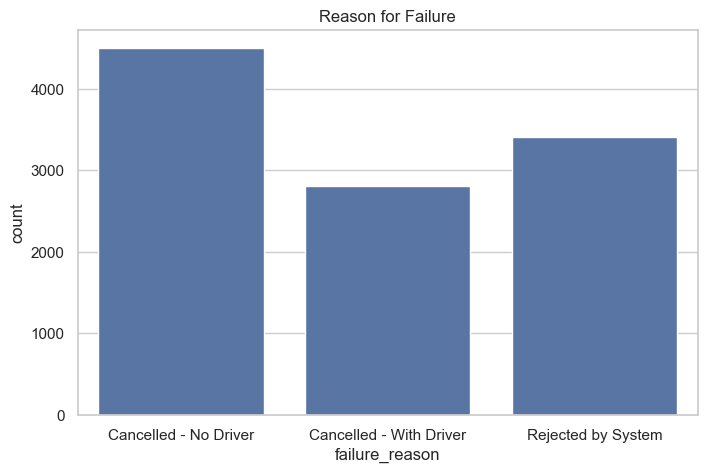

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('data_orders.csv')
offers = pd.read_csv('data_offers.csv')

conditions = [
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 0),
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 1),
    (orders['order_status_key'] == 9)
]

labels = [
    'Cancelled - No Driver',
    'Cancelled - With Driver',
    'Rejected by System'
]

orders['failure_reason'] = np.select(conditions, labels, default='Other')

failure_distribution = orders.groupby('failure_reason').size().reset_index(name='count')

plt.figure(figsize=(8, 5))
sns.barplot(data=failure_distribution, x='failure_reason', y='count')
plt.title("Reason for Failure")
plt.show()






The most interesting insight here is that the biggest failure mode is customers cancelling before a driver is even assigned. This suggests the matching system is too slow — customers are giving up while waiting. It's a supply problem more than a driver behavior problem.
The fact that "Rejected by System" is second reinforces this — the system itself is also failing to match a significant number of orders.
"Cancelled - With Driver" being the lowest is actually a positive signal — once a driver is assigned, customers are less likely to cancel.
